# 06 · Multiclass conformal prediction — chest-pain type
So far the task was the 5-class disease-severity target. Here we switch to a *different* **4-class** target: the **chest-pain type** `cp` (1 typical angina · 2 atypical angina · 3 non-anginal pain · 4 asymptomatic), predicted from the other 12 clinical features. This is a second natural multiclass setting for conformal prediction — a prediction set is now a *set of chest-pain types*, e.g. `{atypical, non-anginal}`.

Everything reuses the same package: only the model becomes a softmax (multinomial) logistic regression, chosen automatically from the number of classes.

In [1]:
# --- workshop bootstrap: make the package importable ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))
import numpy as np, pandas as pd
from fedconformal import data, conformal, evaluate as ev, federated, heterogeneity as het, viz, eda, paper_figures as pf
viz.set_style()
%matplotlib inline
# load the federation once (each notebook is self-contained)
df = data.load_raw()
sites = data.load_sites(shared_scaler=True)
# reload the four sites for the 4-class chest-pain task
sites = data.load_sites(task='cp', shared_scaler=True)
K = data.n_classes('cp'); names = data.class_names('cp')
print('classes:', names)

classes: ['typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic']


## Label shift: chest-pain type varies a lot across sites
Hungary is heavy on *atypical angina*; Switzerland is ~80% *asymptomatic*. This is the multiclass analogue of the disease-prevalence shift from notebook 01.

,typical angina,atypical angina,non-anginal pain,asymptomatic
cleveland,7.6,16.5,28.4,47.5
hungarian,3.7,36.1,18.4,41.8
switzerland,3.3,3.3,13.8,79.7
va,4.0,7.0,23.5,65.5


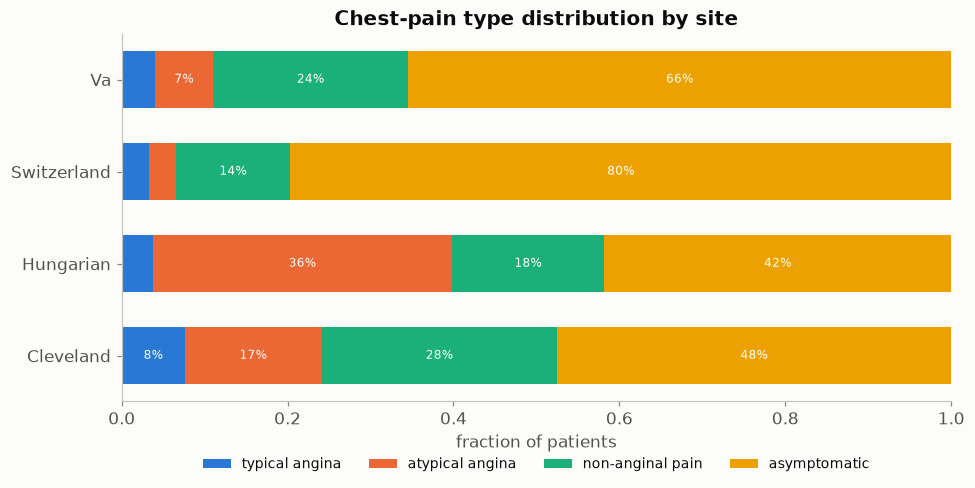

In [2]:
dist = data.class_distribution(sites)
display((dist*100).round(1))
viz.plot_class_distribution_by_site(dist, title='Chest-pain type distribution by site');

## Federated softmax model (hold out Switzerland)
`federated_averaging` detects 4 classes and builds a `SoftmaxModel` automatically.

model: SoftmaxModel | K = 4


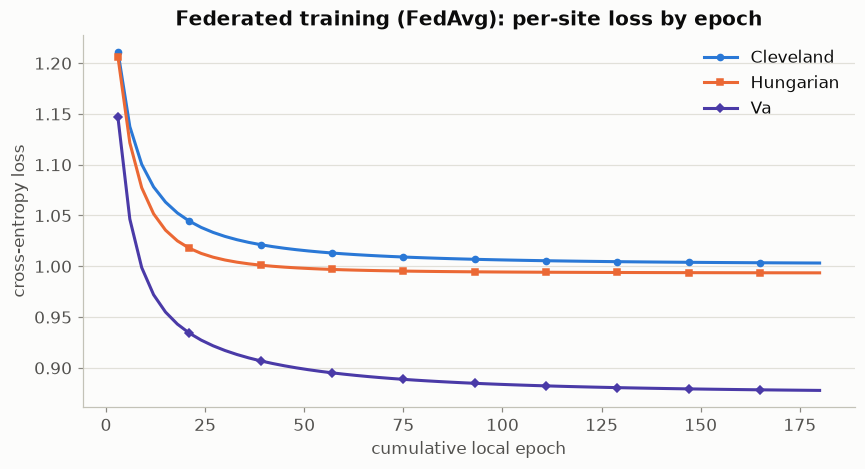

In [3]:
fed = federated.federated_averaging(sites, rounds=60, local_epochs=3,
                                    train_sites=['cleveland','hungarian','va'], seed=0)
model = fed.global_model
print('model:', type(model).__name__, '| K =', model.n_classes)
viz.plot_fed_learning_curves(fed.history);

## Calibrate APS and check coverage
A single split fluctuates; averaged over many splits, marginal coverage sits on 1−α.

In [4]:
import numpy as np
train=['cleveland','hungarian','va']
X=np.vstack([sites[s].X for s in train]); y=np.concatenate([sites[s].y for s in train])
P=model.predict_proba(X)
covs=[]
for seed in range(200):
    r=np.random.default_rng(seed).permutation(len(y)); c,t=r[:len(y)//2], r[len(y)//2:]
    cp=conformal.APSPredictor(alpha=0.1,seed=seed).calibrate(P[c],y[c])
    covs.append(ev.coverage(cp.predict_set(P[t]),y[t]))
print(f'APS mean marginal coverage = {np.mean(covs):.3f}  (target 0.90)')

APS mean marginal coverage = 0.907  (target 0.90)


## The multiclass lesson: class-conditional coverage
Marginal coverage ≈ 90% can hide severe under-coverage of a **rare class**. Calibrate APS on a pooled set and look at coverage *within each true class*.

typical angina     n=  18  coverage=0.333
atypical angina    n=  85  coverage=0.894
non-anginal pain   n=  92  coverage=0.848
asymptomatic       n= 204  coverage=0.985


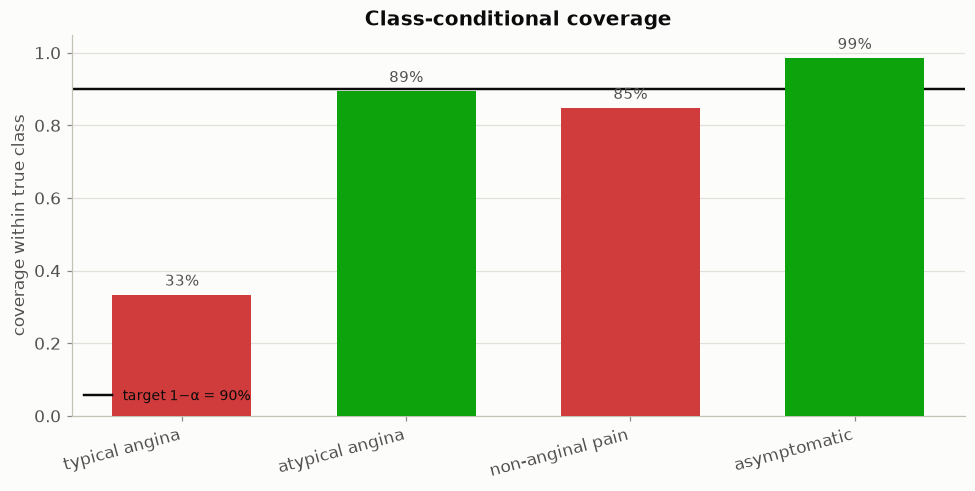

In [5]:
r=np.random.default_rng(1).permutation(len(y)); c,t=r[:len(y)//2], r[len(y)//2:]
cp=conformal.APSPredictor(alpha=0.1,seed=0).calibrate(P[c],y[c])
sets=cp.predict_set(P[t])
cc=ev.class_conditional_coverage(sets,y[t],n_classes=K)
for k,rv in cc.items(): print(f'{names[k]:18s} n={rv["n"]:4d}  coverage={rv["coverage"]:.3f}')
viz.plot_class_conditional_coverage({k:v['coverage'] for k,v in cc.items()}, 0.1, class_names=names);

**Typical angina (the rare class) is badly under-covered**, while *asymptomatic* (the common class) over-covers. Marginal coverage alone would never reveal this — a crucial point when a curation pipeline serves under-represented patient groups.

## Cross-site transfer and prediction-set sizes

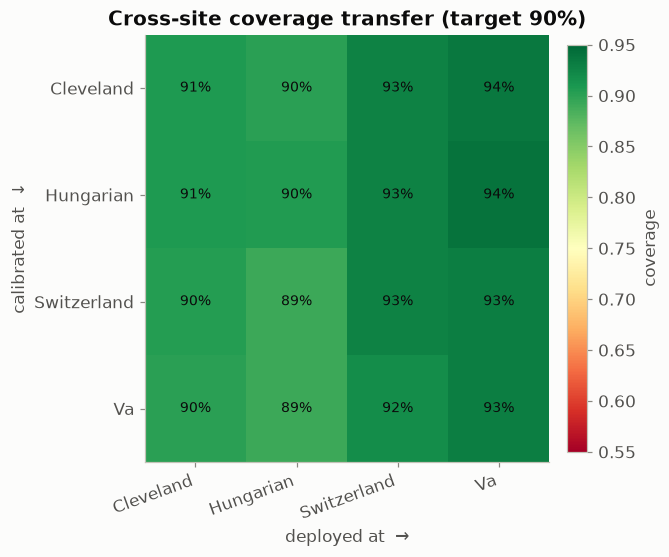

In [6]:
import pandas as pd
cov=pd.DataFrame(index=data.SITES,columns=data.SITES,dtype=float)
for si in data.SITES:
    c=conformal.APSPredictor(alpha=0.1,seed=0).calibrate(model.predict_proba(sites[si].X),sites[si].y)
    for sj in data.SITES:
        cov.loc[si,sj]=ev.coverage(c.predict_set(model.predict_proba(sites[sj].X)),sites[sj].y)
viz.plot_transfer_matrix(cov.astype(float),0.1);

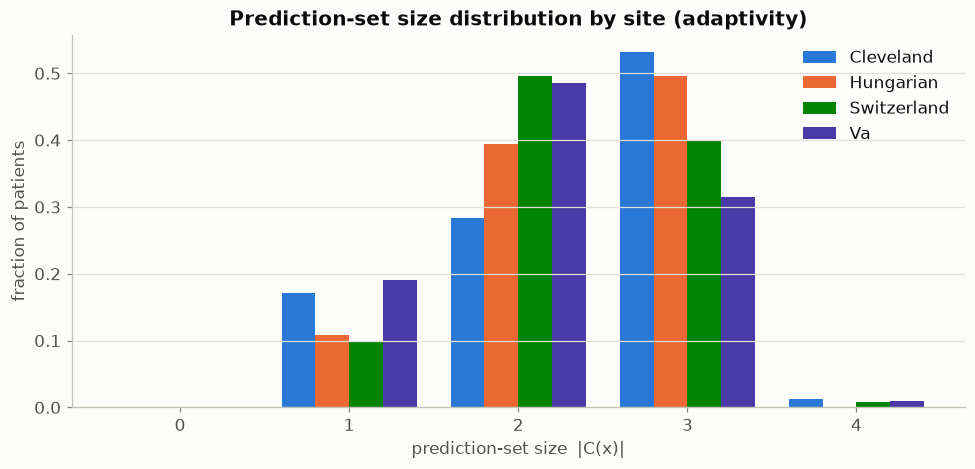

In [7]:
cpc=conformal.APSPredictor(alpha=0.1,seed=0).calibrate(model.predict_proba(sites['cleveland'].X),sites['cleveland'].y)
sizes={s:ev.set_sizes(cpc.predict_set(model.predict_proba(sites[s].X))) for s in data.SITES}
viz.plot_set_size_distribution(sizes, n_classes=K);

### Exercise
1. Switch APS → LAC (`conformal.LACPredictor`) and compare average set size and the class-conditional coverage. Which method is fairer to the rare class?
2. Implement **class-conditional calibration**: fit a separate q̂ per true class (Section 4.2 of the paper). Does it lift typical-angina coverage back to 90%, and what does it cost in average set size?